---
---
# Scifate Demo: Single-Cell RNA Dynamics with `sciflow`

This notebook demonstrates how to load, structure, inspect and analyze a Scifate-style single-cell RNA dataset using the `sciflow` package.


--- 

## Table of Contents

<div style="font-size: 1.15em; line-height: 1.6;">

1. <a href="#1-introduction"><b>Introduction</b></a>  
2. <a href="#2-what-is-scifate"><b>What is Scifate?</b></a>  
3. <a href="#3-loading-the-data"><b>Loading the Data</b></a>  
4. <a href="#4-working-with-the-dataset"><b>Inspecting the Dataset</b></a>  

</div>



---
---

In [3]:
%matplotlib widget

# std lib imports

# 3-party import
import pandas as pd
import numpy as np

# projekt imports
from sciflow.data.scifate_dataset import ScifateDataLoader, ScifateDataset
from sciflow.data import LabeledSparseMatrix, LabeledDistanceMatrix, Dataset

---
---

## 1. Introduction

The goal of this notebook is to demonstrate how `sciflow` handles biological high-dimensional data.






---
---

## 2. What is Scifate?


---
---

## 3. Loading the Data

In the following section, the different data structures used for handling and organizing the dataset are introduced.

--- 

### Data Structures

The package is built around three core data structures:

#### `Dataset`

The `Dataset` class represents the general high-level container for structured datasets.

It stores:

- the underlying data matrix
- sample metadata (`sample_info`)
- feature metadata (`feature_info`)
- dataset-level information such as the dataset name

The class provides a unified interface for accessing dataset dimensions and general dataset properties.


#### `LabeledSparseMatrix`

The `LabeledSparseMatrix` is the central structure used for handling high-dimensional sparse data efficiently.

It combines:

- a sparse matrix representation
- row metadata
- column metadata
- label-aware indexing and filtering

The object supports:

- view-based subsetting without duplicating the underlying matrix
- efficient sparse storage
- metadata-based filtering
- row/column selection
- labeled matrix export as pandas DataFrames

This structure is especially useful for single-cell datasets where matrices are extremely sparse and strongly coupled with metadata.


#### `ScifateDataset`

The `ScifateDataset` extends the generic `Dataset` class and represents a dataset specifically tailored to the SciFate format.

It combines:

- the expression matrix
- optional NTR/RNA dynamics information
- cell metadata
- gene metadata
- trajectory information

The dataset internally uses `LabeledSparseMatrix` objects to store both expression and NTR matrices together with 
their corresponding annotations. This provides a convenient interface for working with biological high-dimensional 
data while keeping sparse operations memory efficient.

---

### Using the `ScifateDataLoader`

To work with a `ScifateDataset`, we use the `ScifateDataLoader` that is responsible for:

- locating the required dataset files  
- reading them from disk  
- ensuring consistent dimensions  
- transforming all matrices into a unified format  
- constructing a structured `ScifateDataset` object  

In [4]:
scifate_loader = ScifateDataLoader()

**Option 1 — Load from folder**

In [5]:
scifate_data = scifate_loader.load(folder_path="/home/nicolas/code/master/higdim/HighDim/data/ScifateData")

**Option 2 — Load from individual files**

In [6]:
scifate_data_ = scifate_loader.load(
    expression_matrix_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/matrix.mtx",
    ntr_matrix_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/4sU.Binom.ntr.mtx",
    barcodes_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/barcodes.tsv",
    features_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/features.tsv",
    trajectories_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/trajectories_sci.csv",
)

Avter we loaded the dataset we can look at the summary to see that everything worked fine.

In [7]:
print(scifate_data.summary())

ScifateDataset(
  name = SciFateDataset,
  shape = 7404 cells x 43750 genes,
  ntr = yes,
  cell_info = yes,
  gene_info = yes
  trajectory = yes
)


---
---

## 4. Working with the Dataset

After loading the dataset, the expression matrix, NTR matrix, and metadata can be accessed directly. The expression_matrix and the ntr_matrix are `LabeledSparseMatrix` objects.
The Gene Info and the Cell Info will be `pandas.Dataframes` that contain multible features that represent infos about the rows and columns of the NTR matrix and expression Matrix.




---

### Inspecting the data within the dataset 

In [8]:
# let's look at the gene info (info about the columns of the ntr and expression matrix)
scifate_data.gene_info.head()

,gene_id,gene_name,feature_type,region,length
0,ENSG00000225602,MTOR-AS1,Gene Expression,Exonic (h.ens90),705
1,ENSG00000171819,ANGPTL7,Gene Expression,Exonic (h.ens90),2238
2,ENSG00000238173,RPL39P6,Gene Expression,Exonic (h.ens90),150
3,ENSG00000239149,SNORA59A,Gene Expression,Exonic (h.ens90),152
4,ENSG00000204518,AADACL4,Gene Expression,Exonic (h.ens90),1575


In [9]:
# let's look at the cell info (info about the rows of the ntr and expression matrix)
scifate_data.cell_info.head()

,barcode,cell_line,time,cell_barcode
0,A549.4h.AAAAACTCTCTCAA,A549,4h,AAAAACTCTCTCAA
1,A549.6h.AAAAAAGAAGTTCA,A549,6h,AAAAAAGAAGTTCA
2,A549.8h.AAAAACGGAGAATA,A549,8h,AAAAACGGAGAATA
3,A549.4h.AAAACGATCCTGGA,A549,4h,AAAACGATCCTGGA
4,A549.6h.AAAAACTGAATTCC,A549,6h,AAAAACTGAATTCC


We can also look and work with the expression_matrix and the NTR matrix in a sparse form and also in a rendered full matrix form.

In [10]:
print(scifate_data.expression_matrix.matrix_sparse[30:60, 30:60])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (30, 30)>
  Coords	Values
  (1, 26)	1
  (4, 7)	1
  (25, 20)	1


In [11]:
print(scifate_data.expression_matrix.head(n = 5))

                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.4h.AAAAACTCTCTCAA         0        0        0         0        0
A549.6h.AAAAAAGAAGTTCA         0        0        0         0        0
A549.8h.AAAAACGGAGAATA         0        0        0         0        0
A549.4h.AAAACGATCCTGGA         0        0        0         0        0
A549.6h.AAAAACTGAATTCC         0        0        0         0        0


In [12]:
print(scifate_data.expression_matrix.summary())

LabeledSparseMatrix(
  name=expression_matrix,
  shape=(7404, 43750),
  dtype=int64,
  not_zero=43838929,
  density=13.5337%,
  is_view=True,
  row_info=['barcode', 'cell_line', 'time', 'cell_barcode'],
  col_info=['gene_id', 'gene_name', 'feature_type', 'region', 'length']
)


---
### Working with the data within the dataset 
Because both expression_matrix and ntr_matrix are `LabeledSparseMatrix` objects we can select data by rows and columns to get a new view on the sparse matrix with that we can work.

In [13]:
expression_matrix = scifate_data.expression_matrix

print(f"Type of expression_matrix: {type(expression_matrix)}")

# selecting diverent properties from the expression matrix
expression_4h = expression_matrix.select_rows(time="4h")

print(f"Type of expression_4h: {type(expression_4h)}")

print()
print(f"Expression Matrix 4h {expression_4h.shape} head:")
print(expression_4h.head(5))

Type of expression_matrix: <class 'sciflow.data.labled_sparse_matrix.LabeledSparseMatrix'>
Type of expression_4h: <class 'sciflow.data.labled_sparse_matrix.LabeledSparseMatrix'>

Expression Matrix 4h (1045, 43750) head:
                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.4h.AAAAACTCTCTCAA         0        0        0         0        0
A549.4h.AAAACGATCCTGGA         0        0        0         0        0
A549.4h.AAAAATAAGAGGCG         0        0        0         0        0
A549.4h.AAAAGAATCGACGT         0        0        0         0        0
A549.4h.AAAAACTAATTGAG         0        0        0         0        0


Because we get a "new" `LabeledSparseMatrix` from the select we can select even further or chain selection operations.

In [14]:
expression_4h_cells = expression_matrix.select_rows(cell_barcode=["AAAAACTCTCTCAA", "AAAACGATCCTGGA", "AAAAATAAGAGGCG"]).select_cols(gene_id=["ENSG00000225602", "ENSG00000171819", "ENSG00000238173"])

print(expression_4h_cells)

                        MTOR-AS1  ANGPTL7  RPL39P6
A549.4h.AAAAACTCTCTCAA         0        0        0
A549.4h.AAAACGATCCTGGA         0        0        0
A549.4h.AAAAATAAGAGGCG         0        0        0


Now we have three diverent `LabeledSparseMatrix` but we dont save the matrix and the infos in all of them the selected ones will just be a view of the original  `LabeledSparseMatrix` 

In [15]:
print(f"Same object:                {id(expression_matrix) == id(expression_4h) == id(expression_4h_cells)}")
print("-" * 35)
print(f"Shared matrix object:       {id(expression_matrix._matrix) == id(expression_4h._matrix) == id(expression_4h_cells._matrix)}")
print(f"Shared row_info object:     {id(expression_matrix._row_info) == id(expression_4h._row_info) == id(expression_4h_cells._row_info)}")
print(f"Shared col_info object:     {id(expression_matrix._col_info) == id(expression_4h._col_info) == id(expression_4h_cells._col_info)}")

Same object:                False
-----------------------------------
Shared matrix object:       True
Shared row_info object:     True
Shared col_info object:     True


---
#### Numpy-like indexing

The `LabeledSparseMatrix` also suports NumPy-like indexing. The returned object is again a `LabeledSparseMatrix`, allowing chained selections and preserving all metadata.

In [16]:
# Select a single element
expression_matrix_entery = scifate_data.expression_matrix[100,100]

print(expression_matrix_entery)

                        TUBB8P11
A549.0h.CTACCCTGCATCAA         0


In [17]:
# Select a single row
expression_matrix_column = scifate_data.expression_matrix[100,:].head(5)

print(expression_matrix_column)

                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.0h.CTACCCTGCATCAA         0        0        0         0        0


In [18]:
# Select a single column
expression_matrix_column = scifate_data.expression_matrix[:,10].head(7)

print(expression_matrix_column)

                         PRAMEF12
A549.4h.AAAAACTCTCTCAA          0
A549.6h.AAAAAAGAAGTTCA          0
A549.8h.AAAAACGGAGAATA          0
A549.4h.AAAACGATCCTGGA          0
A549.6h.AAAAACTGAATTCC          0
A549.2h.AAAAGCCATCAACT          0
A549.10h.AAAATTGAGTATCA         0


In [19]:
# Select with a bolen mask 
mask = (scifate_data.expression_matrix.row_info["time"] == "4h")
expression_matrix_4h = scifate_data.expression_matrix[mask, :]

print(expression_matrix_4h.head(5))

                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.4h.AAAAACTCTCTCAA         0        0        0         0        0
A549.4h.AAAACGATCCTGGA         0        0        0         0        0
A549.4h.AAAAATAAGAGGCG         0        0        0         0        0
A549.4h.AAAAGAATCGACGT         0        0        0         0        0
A549.4h.AAAAACTAATTGAG         0        0        0         0        0


--- 

#### Working with trajectories

Besides the expression and NTR matrices, the dataset also contains trajectory information describing temporal relationships between cells across different time points.
These trajectories can be used to directly extract and analyze dynamic expression patterns over time.

In [20]:
print(f"Barcode (A549.6h.GCGAGGCCTCCATT) is in trajectory with id: {scifate_data.get_trajectory_id(barcode="A549.6h.GCGAGGCCTCCATT")}")

Barcode (A549.6h.GCGAGGCCTCCATT) is in trajectory with id: 5


In [21]:
print(scifate_data.get_trajectory_expression(trajectory_id=5).head(5))

                         MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.8h.AAACAACTACCGAC          0        0        0         0        0
A549.10h.ACCTGGTCCAGGAG         0        0        0         0        0
A549.0h.CTGTAGGTCTATGG          0        0        0         0        0
A549.6h.GCGAGGCCTCCATT          0        0        0         0        0
A549.4h.GCGGATCCTACCTC          0        0        0         0        0


In [22]:
print(scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC").head(5))

                         MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.8h.AAACAACTACCGAC          0        0        0         0        0
A549.10h.ACCTGGTCCAGGAG         0        0        0         0        0
A549.0h.CTGTAGGTCTATGG          0        0        0         0        0
A549.6h.GCGAGGCCTCCATT          0        0        0         0        0
A549.4h.GCGGATCCTACCTC          0        0        0         0        0


---
---
## 4. Distances and Heatmaps on parts of the data matrices

---

### Distance Metrics

Different biological questions often require different notions of similarity. The package therefore provides multiple interchangeable distance metrics built on top of a shared `BaseDistance` interface. All distance metrics support direct pairwise comparisons as well as full pairwise distance matrix computation. Some of them also suport working with sparse matrixes the others work with the hole matrix. 

--- 
#### The two distances used in the following are:

##### Cosine Distance
Instead of comparing absolute magnitudes, it compares the **direction** of two expression vectors:

$$
d_{\text{cos}}(x, y)
=
1 -
\frac{x^\top y}
{\|x\|\|y\|}
$$


##### Correlation Distance
Correlation distance compares the **relative variation structure** between vectors:

$$
d_{\text{corr}}(x, y)
=
1 -
\frac{(x - \bar{x})^\top (y - \bar{y})}
{\|x - \bar{x}\| \, \|y - \bar{y}\|}
$$

Instead of absolute expression values, it focuses on up/down regulation patterns and the relative feature behavior.
Because centering destroys sparsity, correlation distance internally operates on dense representations.


In [32]:
from sciflow.distance import CorrelationDistance, CosineDistance, EuclideanDistance

---
### Distance Matrices

The dataset supports the creation of pairwise distance matrices for different biological entities such as cells, genes, and trajectories.
Distance matrices can be computed from both the expression matrix and the NTR matrix using different distance metrics including cosine, 
euclidean, correlation, and ranking-based distances. Internally, the rows are always interpreted as data points and the columns as features. 

For example:

- cell distances:
  rows = cells, columns = genes

- gene distances:
  rows = genes, columns = cells

- trajectory distances:
  rows = trajectories, columns = concatenated trajectory features

The resulting distance matrices are stored as `LabeledDistanceMatrix` objects and can optionally be cached inside the dataset for later reuse.

In [24]:
# Calculate the distance betweean diverent cells
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                                 # This will give us 5 Cells with each 40k genes  
cells_dist_matrix = scifate_data.create_distance_matrix(matrix=expression_cells, distance=CorrelationDistance(), entity="cell", data="expression", save=True)

CorrelationDistance: 100%|██████████| 6/6 [00:00<00:00, 2439.26it/s]


In [25]:
# Calculate the distance betweean diverent genes
expression_genes = scifate_data.expression_matrix[:, 10:20].T                                                                 # here we need to transpose the matrix because we always    
genes_dist_matrix = scifate_data.create_distance_matrix(matrix=expression_genes, distance=EuclideanDistance())

In [26]:
# Calculate the distance berwean diveren trajectorys 
trajectory_dist_matrix = scifate_data.create_distance_matrix(entity="trajectory", data="expression", distance=CosineDistance())

---
### Visualizing the Distance matrices

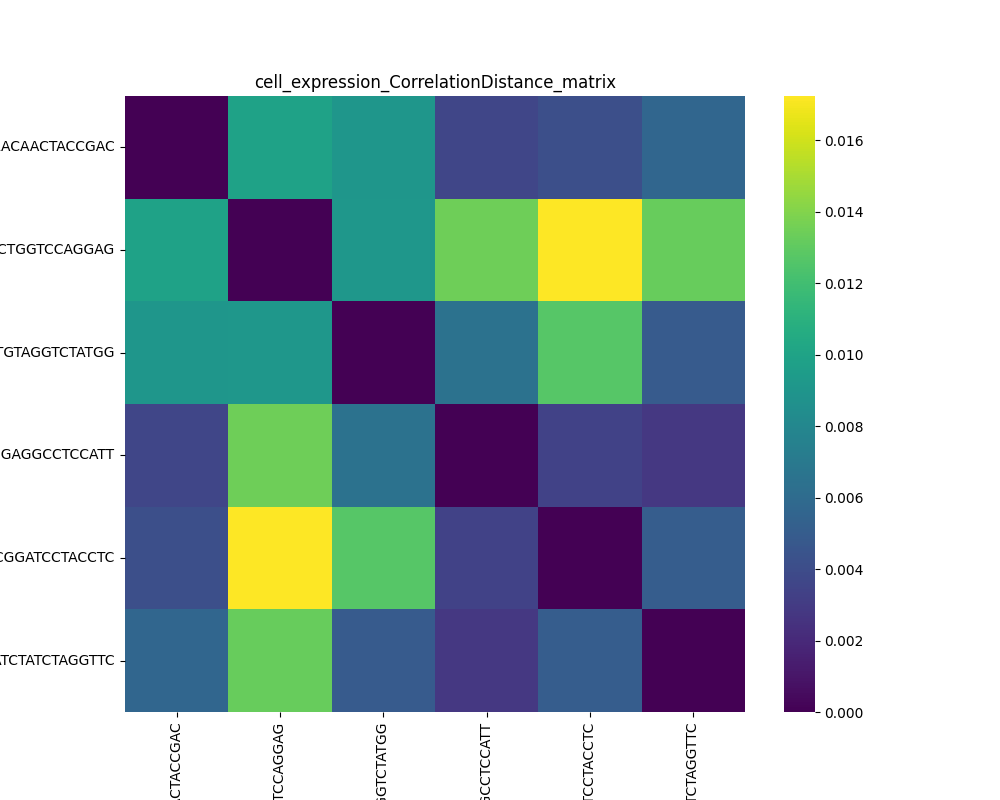

In [27]:
from sciflow.plotting.scifate_plotter import ScifatePlotter

plotter = ScifatePlotter()

fig =  plotter.plot_matrix(matrix=cells_dist_matrix)

# TODO

---

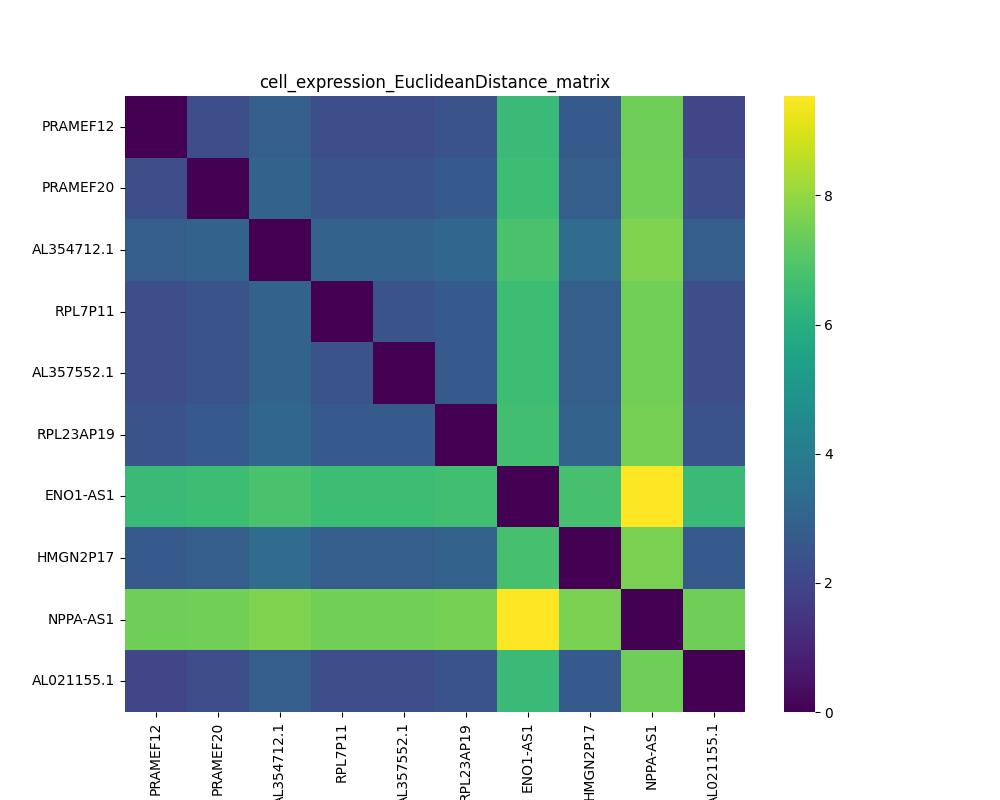

In [28]:
fig =  plotter.plot_matrix(matrix=genes_dist_matrix)

# TODO

---

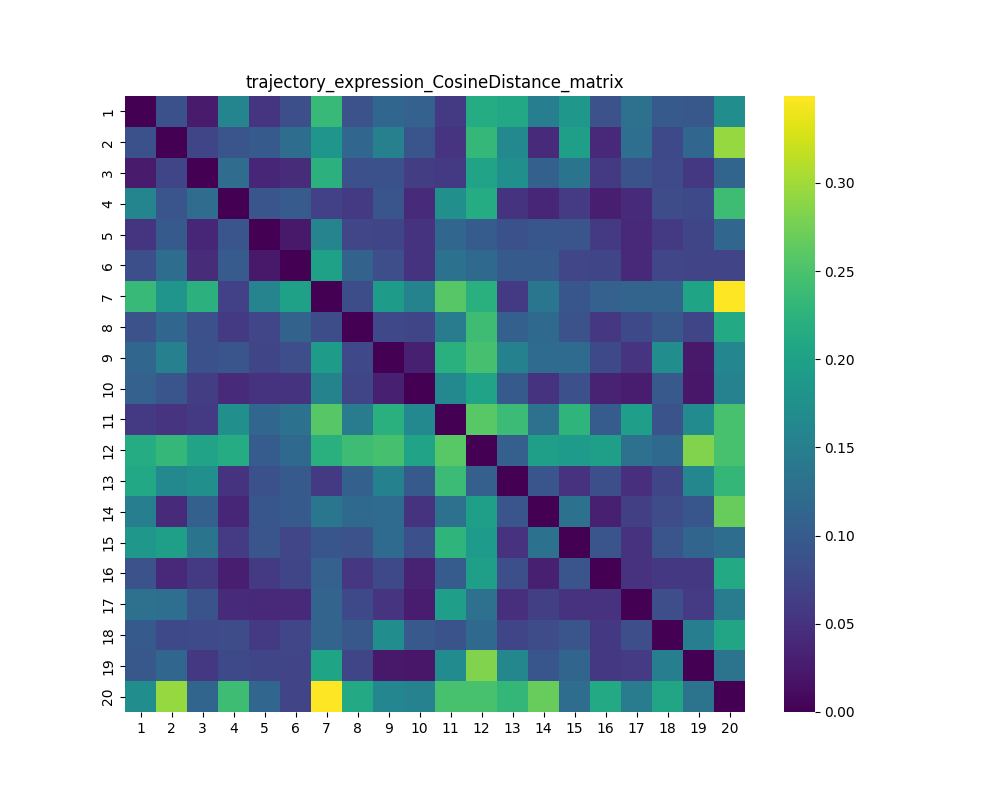

In [29]:
fig =  plotter.plot_matrix(matrix=trajectory_dist_matrix[:20, :20])

---
---
## 5. Distance Matrix on whole Data

For large single-cell datasets, directly computing distances in the original high-dimensional gene space can become computationally expensive. To address this, random projections can be used to project the data into a lower-dimensional space while still approximately preserving the distances between cells. Under certain conditions, the projected distances remain close to the original distances of the high-dimensional data. This makes it possible to compute distance matrices more efficiently without completely losing the geometric structure of the dataset.

One important theoretical foundation is the Johnson–Lindenstrauss lemma. It states that a set of n points can be projected into a significantly lower-dimensional space such that pairwise distances are preserved up to a small error. More formally, for an error parameter $\varepsilon \in (0, 1)$, there exists a projection into dimension:

$k = \mathcal{O}\left(\frac{\log n}{\varepsilon^2}\right)$.

such that the distances between all pairs of points are approximately maintained with high probability. This provides the theoretical basis for using random projections in large-scale distance computations.

In [31]:

print(f"Max Row Density: {int(scifate_data.expression_matrix.max_row_density() * scifate_data.expression_matrix.n_cols)} out of {scifate_data.expression_matrix.n_cols}" )
print(f"Mean Row Density: {int(np.mean(scifate_data.expression_matrix.row_density()) *  scifate_data.expression_matrix.n_cols)} out of {scifate_data.expression_matrix.n_cols}" )
print(f"Median Row Density: {int(np.median(scifate_data.expression_matrix.row_density()) *  scifate_data.expression_matrix.n_cols)} out of {scifate_data.expression_matrix.n_cols}" )
print()

print(f"Max Column Density: {int(scifate_data.expression_matrix.max_col_density() * scifate_data.expression_matrix.n_rows)} out of {scifate_data.expression_matrix.n_rows}" )
print(f"Mean Column Density: {int(np.mean(scifate_data.expression_matrix.col_density()) * scifate_data.expression_matrix.n_rows)} out of {scifate_data.expression_matrix.n_rows}" )
print(f"Median Column Density: {int(np.median(scifate_data.expression_matrix.col_density()) * scifate_data.expression_matrix.n_rows)} out of {scifate_data.expression_matrix.n_rows}" )

Max Row Density: 9274 out of 43750
Mean Row Density: 5920 out of 43750
Median Row Density: 5947 out of 43750

Max Column Density: 7404 out of 7404
Mean Column Density: 1002 out of 7404
Median Column Density: 30 out of 7404


---
---
## 6. Clustering Methods

---
---
## 7. Dimension reduction and ploting the data